In [3]:
from IPython.display import HTML

HTML('''<script>
code_show=true; 
function code_toggle() {
 if (code_show){
 $('div.input').hide();
 } else {
 $('div.input').show();
 }
 code_show = !code_show
} 
$( document ).ready(code_toggle);
</script>
<form action="javascript:code_toggle()"><input type="submit" value="Toggle Code On/Off"></form>''')


# Proof of Concept: Open Banking Early Warning System (EWS) for Credit Risk
**Objective:** Transitioning from lagging credit bureau indicators to real-time behavioral leading indicators (Open Banking)

**Prepared for:** Advanced Financial Solutions (AFS) | Advisory Services

## 1. Data Generation & Dictionary

To simulate an Open Banking environment, we generated a synthetic dataset representing 6 months of daily transaction logs. The data includes a hidden 5% subset of accounts that experience simulated financial deterioration (e.g., job loss, rising short-term debt) in the final two months.

**Timeframe:** January 2025 to June 2025 (6 Months)

### Data Dictionary
**1. Customer Base (`customers_df`)**
* `customer_id`: Unique identifier for the retail banking customer.
* `age`: Customer age (21 - 65).
* `declared_income_band`: Initial income classification (Low, Medium, High).
* `is_default_bound`: Ground truth flag (1 = Defaulting soon, 0 = Healthy). *Hidden from the model.*

**2. Transaction Ledger (`transactions_df`)**
* `transaction_id`: Unique identifier for the Open Banking API event.
* `customer_id`: Link to the customer table.
* `transaction_date`: Date of the transaction.
* `transaction_type`: 'Credit' (Inflow) or 'Debit' (Outflow).
* `transaction_category`: Open Banking categorization (Salary, Housing, Short_Term_Credit, Utilities, Groceries, Dining, Entertainment, Transport).
* `amount`: Transaction value in standard currency.

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import uuid

# Set seed for reproducibility
np.random.seed(42)

def generate_open_banking_data(num_customers=1000, default_rate=0.05, months=6):
    print("Initializing synthetic Open Banking data generation...")
    
    # ---------------------------------------------------------
    # 1. GENERATE CUSTOMER-LEVEL DATA (The Ground Truth)
    # ---------------------------------------------------------
    customers = pd.DataFrame({
        'customer_id': [f"CUST_{str(i).zfill(4)}" for i in range(1, num_customers + 1)],
        'age': np.random.randint(21, 65, num_customers),
        'declared_income_band': np.random.choice(['Low', 'Medium', 'High'], num_customers, p=[0.4, 0.4, 0.2]),
        'is_default_bound': np.random.choice([0, 1], num_customers, p=[1 - default_rate, default_rate])
    })

    # ---------------------------------------------------------
    # 2. GENERATE TRANSACTION-LEVEL DATA (Raw Event Logs)
    # ---------------------------------------------------------
    start_date = datetime(2025, 1, 1)
    transactions = []

    for _, row in customers.iterrows():
        cid = row['customer_id']
        is_def = row['is_default_bound']
        
        # Base monthly income profile
        base_salary = 2500 if row['declared_income_band'] == 'Low' else 5000 if row['declared_income_band'] == 'Medium' else 9000
        
        # Loop through each month to generate transactions
        for month_offset in range(months):
            month_start = start_date + timedelta(days=month_offset * 30)
            
            # --- Deterioration Logic for Default-Bound Accounts ---
            # In the last 2 months, default-bound accounts experience financial stress
            if is_def and month_offset >= (months - 2):
                actual_salary = base_salary * np.random.choice([0.0, 0.4, 1.0], p=[0.2, 0.5, 0.3]) # Paycuts or job loss
                bnpl_count = np.random.randint(4, 10) # Heavy reliance on short-term debt
                discretionary_spend_multiplier = 1.5 # Erratic spending
            else:
                actual_salary = base_salary
                bnpl_count = np.random.randint(0, 3)
                discretionary_spend_multiplier = 1.0

            # 1. Income (Credit)
            if actual_salary > 0:
                salary_date = month_start + timedelta(days=np.random.randint(0, 3))
                transactions.append([cid, salary_date, 'Credit', 'Salary', round(actual_salary, 2)])
                
            # 2. Fixed Expenses: Housing/Rent (Debit)
            rent_date = month_start + timedelta(days=np.random.randint(3, 7))
            transactions.append([cid, rent_date, 'Debit', 'Housing', round(base_salary * 0.35, 2)])
            
            # 3. Debt Servicing: BNPL / Microfinance (Debit)
            for _ in range(bnpl_count):
                bnpl_date = month_start + timedelta(days=np.random.randint(1, 28))
                transactions.append([cid, bnpl_date, 'Debit', 'Short_Term_Credit', round(np.random.uniform(50, 300), 2)])
                
            # 4. Utilities & Essentials (Debit)
            for _ in range(np.random.randint(3, 6)):
                util_date = month_start + timedelta(days=np.random.randint(1, 28))
                transactions.append([cid, util_date, 'Debit', 'Utilities_Essentials', round(np.random.uniform(20, 100), 2)])

            # 5. Discretionary Spend / Groceries (Debit)
            num_discretionary = int(np.random.randint(10, 25) * discretionary_spend_multiplier)
            for _ in range(num_discretionary):
                spend_date = month_start + timedelta(days=np.random.randint(1, 28))
                category = np.random.choice(['Groceries', 'Dining', 'Entertainment', 'Transport'])
                transactions.append([cid, spend_date, 'Debit', category, round(np.random.uniform(10, 150), 2)])

    # Compile Transaction DataFrame
    txn_df = pd.DataFrame(transactions, columns=[
        'customer_id', 'transaction_date', 'transaction_type', 'transaction_category', 'amount'
    ])
    
    # Add unique transaction IDs and sort chronologically per customer
    txn_df['transaction_id'] = [str(uuid.uuid4())[:8] for _ in range(len(txn_df))]
    txn_df = txn_df[['transaction_id', 'customer_id', 'transaction_date', 'transaction_type', 'transaction_category', 'amount']]
    txn_df = txn_df.sort_values(by=['customer_id', 'transaction_date']).reset_index(drop=True)

    print(f"Success! Generated {len(customers)} customers and {len(txn_df)} raw transactions.")
    return customers, txn_df

# Execute generation
customers_df, transactions_df = generate_open_banking_data()

# Save to CSV (Optional, for you to review locally)
customers_df.to_csv("ob_customers_raw.csv", index=False)
transactions_df.to_csv("ob_transactions_raw.csv", index=False)

# Display sample output
print("\n--- Customer Data Sample ---")
print(customers_df.head(3))
print("\n--- Transaction Data Sample ---")
print(transactions_df.head(5))

Initializing synthetic Open Banking data generation...
Success! Generated 1000 customers and 145098 raw transactions.

--- Customer Data Sample ---
  customer_id  age declared_income_band  is_default_bound
0   CUST_0001   59               Medium                 0
1   CUST_0002   49                  Low                 0
2   CUST_0003   35                 High                 0

--- Transaction Data Sample ---
  transaction_id customer_id transaction_date transaction_type  \
0       a11201af   CUST_0001       2025-01-03           Credit   
1       5ff584f6   CUST_0001       2025-01-05            Debit   
2       dfd2a5fa   CUST_0001       2025-01-07            Debit   
3       d3298e23   CUST_0001       2025-01-07            Debit   
4       b58b6148   CUST_0001       2025-01-07            Debit   

  transaction_category   amount  
0               Salary  5000.00  
1        Entertainment    79.75  
2              Housing  1750.00  
3        Entertainment   116.55  
4               Dini

In [5]:
from IPython.display import display, HTML

# Calculate basic stats
total_customers = customers_df['customer_id'].nunique()
total_txns = len(transactions_df)
total_volume = transactions_df['amount'].sum()
default_rate = customers_df['is_default_bound'].mean() * 100

# HTML for KPI Tiles
html_str = f"""
<div style="display: flex; justify-content: space-between; margin-bottom: 20px;">
    <div style="background-color: #f4f6f9; padding: 20px; border-radius: 10px; width: 22%; text-align: center; box-shadow: 2px 2px 5px rgba(0,0,0,0.1);">
        <h3 style="margin: 0; color: #333;">Total Customers</h3>
        <h1 style="margin: 5px 0; color: #0056b3;">{total_customers:,}</h1>
    </div>
    <div style="background-color: #f4f6f9; padding: 20px; border-radius: 10px; width: 22%; text-align: center; box-shadow: 2px 2px 5px rgba(0,0,0,0.1);">
        <h3 style="margin: 0; color: #333;">Total Transactions</h3>
        <h1 style="margin: 5px 0; color: #0056b3;">{total_txns:,}</h1>
    </div>
    <div style="background-color: #f4f6f9; padding: 20px; border-radius: 10px; width: 22%; text-align: center; box-shadow: 2px 2px 5px rgba(0,0,0,0.1);">
        <h3 style="margin: 0; color: #333;">Total Volume ($)</h3>
        <h1 style="margin: 5px 0; color: #0056b3;">${total_volume:,.0f}</h1>
    </div>
    <div style="background-color: #f4f6f9; padding: 20px; border-radius: 10px; width: 22%; text-align: center; box-shadow: 2px 2px 5px rgba(0,0,0,0.1);">
        <h3 style="margin: 0; color: #333;">Default-Bound %</h3>
        <h1 style="margin: 5px 0; color: #d9534f;">{default_rate:.1f}%</h1>
    </div>
</div>
"""
display(HTML(html_str))

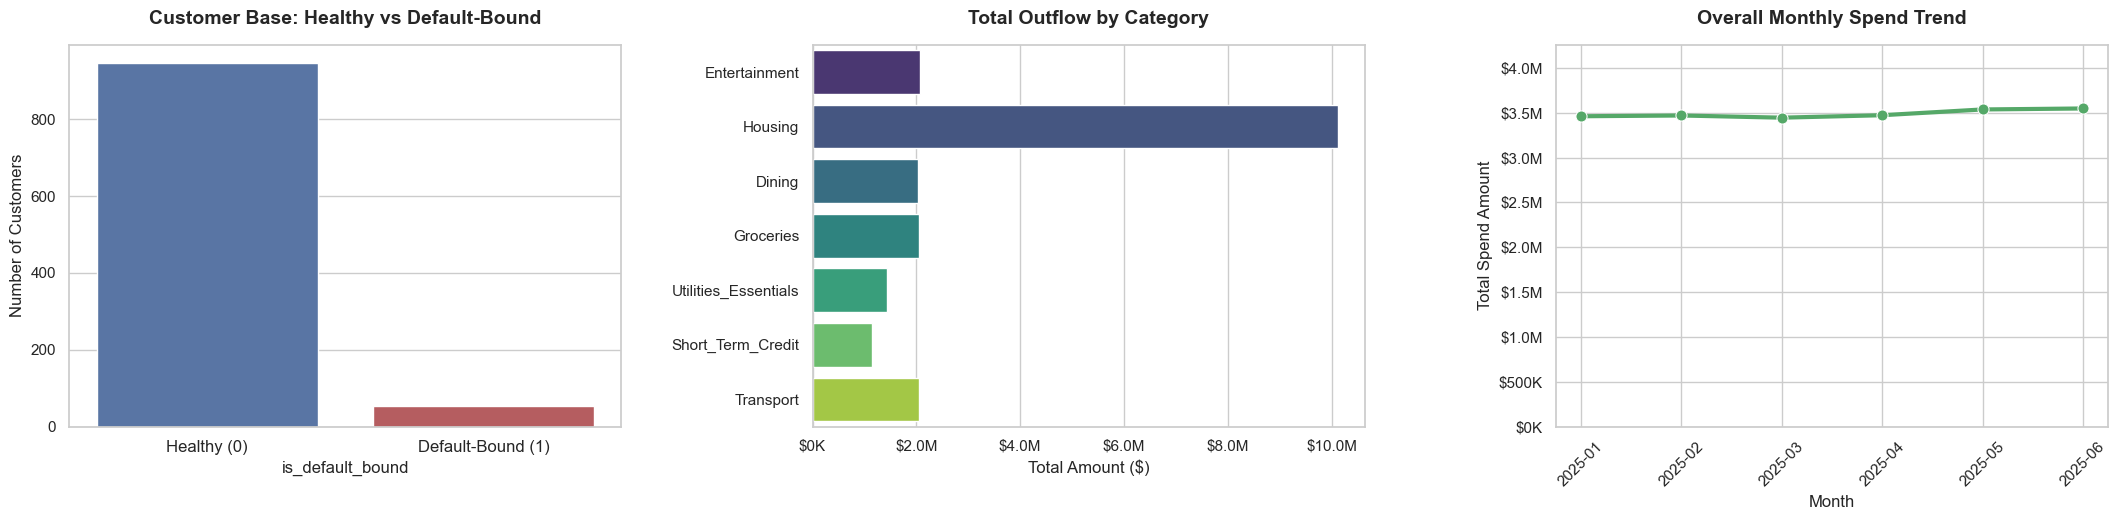

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# --- Data Prep Fix: Create 'month' BEFORE splitting ---
transactions_df['month_period'] = transactions_df['transaction_date'].dt.to_period('M').astype(str)
debits = transactions_df[transactions_df['transaction_type'] == 'Debit']

# Set visual style and larger canvas
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6)) # Increased width for better spacing

# 1. Customer Level: Target Distribution
sns.countplot(data=customers_df, x='is_default_bound', palette=['#4C72B0', '#C44E52'], ax=axes[0])
axes[0].set_title('Customer Base: Healthy vs Default-Bound', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xticklabels(['Healthy (0)', 'Default-Bound (1)'], fontsize=12)
axes[0].set_ylabel('Number of Customers', fontsize=12)

# Formatter to show millions (M) or thousands (K)
def currency_formatter(x, pos):
    if x >= 1e6: return f'${x*1e-6:.1f}M'
    return f'${x*1e-3:.0f}K'

# 2. Transaction Level: Spend by Category
# Fixed 'ci' deprecation by using 'errorbar=None'
sns.barplot(data=debits, y='transaction_category', x='amount', estimator=sum, errorbar=None, palette='viridis', ax=axes[1])
axes[1].set_title('Total Outflow by Category', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Total Amount ($)', fontsize=12)
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(FuncFormatter(currency_formatter))

# 3. Time-Series: Monthly Spend Trend
monthly_spend = debits.groupby('month_period')['amount'].sum().reset_index()
sns.lineplot(data=monthly_spend, x='month_period', y='amount', marker='o', linewidth=3, markersize=8, color='#55A868', ax=axes[2])
axes[2].set_title('Overall Monthly Spend Trend', fontsize=14, fontweight='bold', pad=15)
axes[2].set_xlabel('Month', fontsize=12)
axes[2].set_ylabel('Total Spend Amount', fontsize=12)
axes[2].set_ylim(0, monthly_spend['amount'].max() * 1.2) # Forces Y-axis to start at 0
axes[2].yaxis.set_major_formatter(FuncFormatter(currency_formatter))
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout(pad=3.0)
plt.show()

## 2. Feature Engineering: Translating Raw Behavior into Risk Signals

Traditional credit scorecards rely on lagging indicators, such as missed payments reported to credit bureaus 30 to 60 days after the fact. To build an effective Open Banking Early Warning System (EWS) that supports dynamic IFRS 9 Stage 2 classification, we must engineer raw transaction data into real-time **leading indicators**. 

I extracted 8 behavioral features from the raw data, categorized into four key risk dimensions:

### A. Income Stability
1. **Salary Shock Ratio** *(Current Salary / Historical Average)*
   * **Why I added it:** It immediately detects severe top-line shocks like job loss, pay cuts, or a shift from full-time to gig-economy work.
2. **Income Latency** *(Current Pay Day - Historical Average Pay Day)*
   * **Why I added it:** If a customer who is reliably paid on the 1st gets paid on the 5th, it signals employer distress or erratic gig income, disrupting the ability to clear scheduled auto-debits.

### B. Debt & Leverage Pressure
3. **BNPL / Short-Term Debt Velocity** *(Current Month Micro-loan Count - Historical Average)*
   * **Why I added it:** A sudden spike in Buy-Now-Pay-Later (BNPL) or payday loan usage is one of the strongest leading indicators of default. It shows the customer is seeking fast, alternative liquidity to bridge a cash gap.
4. **DTI Trend** *(Current Month Debt-to-Income Ratio - Historical Average DTI)*
   * **Why I added it:** A static DTI isn't a warning; a *rising* DTI is. This captures customers who are actively becoming structurally over-indebted before traditional credit bureaus update their files.

### C. Liquidity & Cash Flow
5. **Cash Buffer Depletion** *(Current Month Lowest Balance - Previous Month Lowest Balance)*
   * **Why I added it:** Tracks the depletion of the customer's safety net. A negative trend means the customer is consistently burning through their historical cash buffer.
6. **Net Cash Flow** *(Total Income - Total Outflows)*
   * **Why I added it:** A fundamental check. If this is persistently negative, the customer is relying on external credit to survive the month.

### D. Behavioral Stress 
7. **Discretionary Spend Squeeze** *(Current Discretionary Ratio - Historical Discretionary Ratio)*
   * **Why I added it:** Consumer behavior changes before a default. A sharp drop indicates the customer has entered "survival mode" and is actively cutting non-essential spend to ration cash.
8. **Essential Spend Drop** *(Current Utilities & Groceries / Historical Average)*
   * **Why I added it:** If a customer suddenly drops their utility payments or drastically cuts grocery spending, it indicates severe distress where even basic living expenses are becoming unmanageable.

In [7]:
import pandas as pd
import numpy as np

print("Starting Feature Engineering...")

# 1. Calculate Daily Running Balance
# Create signed amounts (+ for Credit, - for Debit)
transactions_df['signed_amount'] = np.where(
    transactions_df['transaction_type'] == 'Credit', 
    transactions_df['amount'], 
    -transactions_df['amount']
)

# Sort strictly by time and calculate cumulative sum for running balance
transactions_df = transactions_df.sort_values(by=['customer_id', 'transaction_date'])
transactions_df['running_balance'] = transactions_df.groupby('customer_id')['signed_amount'].cumsum()

# 2. Extract Month for Aggregation
transactions_df['month'] = transactions_df['transaction_date'].dt.month
transactions_df['day_of_month'] = transactions_df['transaction_date'].dt.day

# 3. Create analytical base per customer
final_features = []

for cust_id in customers_df['customer_id']:
    cust_txns = transactions_df[transactions_df['customer_id'] == cust_id]
    
    # Split into History (Months 1-5) and Current Month (Month 6)
    history = cust_txns[cust_txns['month'] < 6]
    current = cust_txns[cust_txns['month'] == 6]
    
    if len(history) == 0 or len(current) == 0:
        continue
        
    # --- Helper Data for Current Month ---
    curr_salary_txns = current[current['transaction_category'] == 'Salary']
    curr_salary = curr_salary_txns['amount'].sum()
    curr_debits = current[current['transaction_type'] == 'Debit']
    curr_total_debits = curr_debits['amount'].sum() if not curr_debits.empty else 1
    
    # --- FEATURE 1: Income Volatility (Salary Shock Ratio) ---
    hist_monthly_salary = history[history['transaction_category'] == 'Salary'].groupby('month')['amount'].sum()
    avg_hist_salary = hist_monthly_salary.mean() if not hist_monthly_salary.empty else 0
    salary_shock_ratio = curr_salary / avg_hist_salary if avg_hist_salary > 0 else 1.0
    
    # --- FEATURE 2: Income Latency (Days Late) ---
    hist_salary_days = history[history['transaction_category'] == 'Salary']['day_of_month']
    avg_hist_salary_day = hist_salary_days.mean() if not hist_salary_days.empty else 1
    curr_salary_day = curr_salary_txns['day_of_month'].mean() if not curr_salary_txns.empty else avg_hist_salary_day
    income_latency_days = curr_salary_day - avg_hist_salary_day
    
    # --- FEATURE 3: Liquidity Trend (Min Balance Shift) ---
    # Compare the lowest balance of Month 6 vs Month 5
    month_5 = history[history['month'] == 5]
    min_bal_m5 = month_5['running_balance'].min() if not month_5.empty else 0
    min_bal_m6 = current['running_balance'].min()
    min_balance_trend = min_bal_m6 - min_bal_m5
    
    # --- FEATURE 4: BNPL / Short-Term Debt Velocity ---
    hist_bnpl_counts = history[history['transaction_category'] == 'Short_Term_Credit'].groupby('month').size()
    avg_hist_bnpl_count = hist_bnpl_counts.mean() if not hist_bnpl_counts.empty else 0
    curr_bnpl_count = len(current[current['transaction_category'] == 'Short_Term_Credit'])
    bnpl_velocity_spike = curr_bnpl_count - avg_hist_bnpl_count
    
# --- FEATURE 5: DTI Proxy Trend (Current DTI vs Historical DTI) ---
    curr_housing = current[current['transaction_category'] == 'Housing']['amount'].sum()
    curr_bnpl = current[current['transaction_category'] == 'Short_Term_Credit']['amount'].sum()
    curr_dti = (curr_housing + curr_bnpl) / (curr_salary if curr_salary > 0 else 1)
    
    hist_housing = history[history['transaction_category'] == 'Housing'].groupby('month')['amount'].sum().mean()
    hist_bnpl = history[history['transaction_category'] == 'Short_Term_Credit'].groupby('month')['amount'].sum().mean()
    hist_salary = history[history['transaction_category'] == 'Salary'].groupby('month')['amount'].sum().mean()
    hist_dti = (hist_housing + hist_bnpl) / (hist_salary if hist_salary > 0 else 1)
    
    dti_trend = curr_dti - hist_dti # Positive value means debt burden is increasing
    
    # --- FEATURE 6: Discretionary Spend Squeeze (Current Ratio vs Historical Ratio) ---
    curr_discretionary = current[current['transaction_category'].isin(['Dining', 'Entertainment'])]['amount'].sum()
    curr_disc_ratio = curr_discretionary / curr_total_debits
    
    hist_disc = history[history['transaction_category'].isin(['Dining', 'Entertainment'])].groupby('month')['amount'].sum().mean()
    hist_debits = history[history['transaction_type'] == 'Debit'].groupby('month')['amount'].sum().mean()
    hist_disc_ratio = hist_disc / (hist_debits if hist_debits > 0 else 1)
    
    discretionary_squeeze = curr_disc_ratio - hist_disc_ratio # Negative value means they are actively cutting fun spend
    
    # --- FEATURE 7: Essential Spend Drop (Current vs Historical) ---
    # Instead of historical standard deviation, we check if they suddenly stopped paying bills in the current month
    curr_essentials = current[current['transaction_category'].isin(['Utilities_Essentials', 'Groceries'])]['amount'].sum()
    hist_essentials = history[history['transaction_category'].isin(['Utilities_Essentials', 'Groceries'])].groupby('month')['amount'].sum().mean()
    
    essential_spend_drop = curr_essentials / (hist_essentials if hist_essentials > 0 else 1)
    
    # --- FEATURE 8: Net Cash Flow ---
    net_cash_flow = curr_salary - curr_total_debits

    # Append to features list
    final_features.append({
        'customer_id': cust_id,
        'salary_shock_ratio': round(salary_shock_ratio, 3),
        'income_latency_days': round(income_latency_days, 1),
        'min_balance_trend': round(min_balance_trend, 2),
        'bnpl_velocity_spike': round(bnpl_velocity_spike, 1),
        'dti_trend': round(dti_trend, 3),
        'discretionary_squeeze': round(discretionary_squeeze, 3),
        'essential_spend_drop': round(essential_spend_drop, 2),
        'net_cash_flow': round(net_cash_flow, 2)
    })

# Compile and merge with target variable
features_df = pd.DataFrame(final_features)
# Fill NaN values that might arise from standard deviation calculations on empty arrays
features_df.fillna(0, inplace=True) 

analytics_df = pd.merge(features_df, customers_df[['customer_id', 'is_default_bound']], on='customer_id')

print("Feature Engineering Complete! Engineered Dataset Shape:", analytics_df.shape)
display(analytics_df.head())


Starting Feature Engineering...
Feature Engineering Complete! Engineered Dataset Shape: (1000, 10)


,customer_id,salary_shock_ratio,income_latency_days,min_balance_trend,bnpl_velocity_spike,dti_trend,discretionary_squeeze,essential_spend_drop,net_cash_flow,is_default_bound
0,CUST_0001,0.8,-7.2,1364.72,-0.8,0.072,-0.021,1.29,1364.72,0
1,CUST_0002,0.8,-7.4,-445.53,-1.5,-0.031,0.057,1.48,-445.53,0
2,CUST_0003,1.0,0.6,3564.81,0.7,-0.001,0.034,1.46,3564.81,0
3,CUST_0004,0.0,0.0,1831.36,-0.7,1898.473,-0.010,2.08,-4612.22,0
4,CUST_0005,1.0,-1.4,-616.80,-1.8,-0.112,0.111,1.33,-616.80,0


## 3. Multicollinearity Check & Feature Pruning

Before training a Logistic Regression model, we must check for **Multicollinearity** (when two or more features measure the exact same underlying behavior). 

**Why it matters for IFRS 9 / Regulatory Compliance:**
If we feed highly correlated features into Logistic Regression, the mathematical coefficients become unstable and the p-values become inaccurate. The model might assign a massive positive weight to one feature and a massive negative weight to another to cancel them out, entirely ruining the explainability of the scorecard.

We will generate a correlation matrix, identify redundant features, and drop them to ensure every variable provides an independent risk signal.

🚨 MULTICOLLINEARITY DETECTED 🚨
Observation: 'net_cash_flow' and 'dti_trend' show massive correlation (>0.80) with 'salary_shock_ratio'.
Reason: All three mathematically rely on current salary. They are telling the model the exact same story.
Action: Keeping 'salary_shock_ratio' (the purest indicator of income distress) and dropping the derivative metrics to stabilize the model's coefficients.



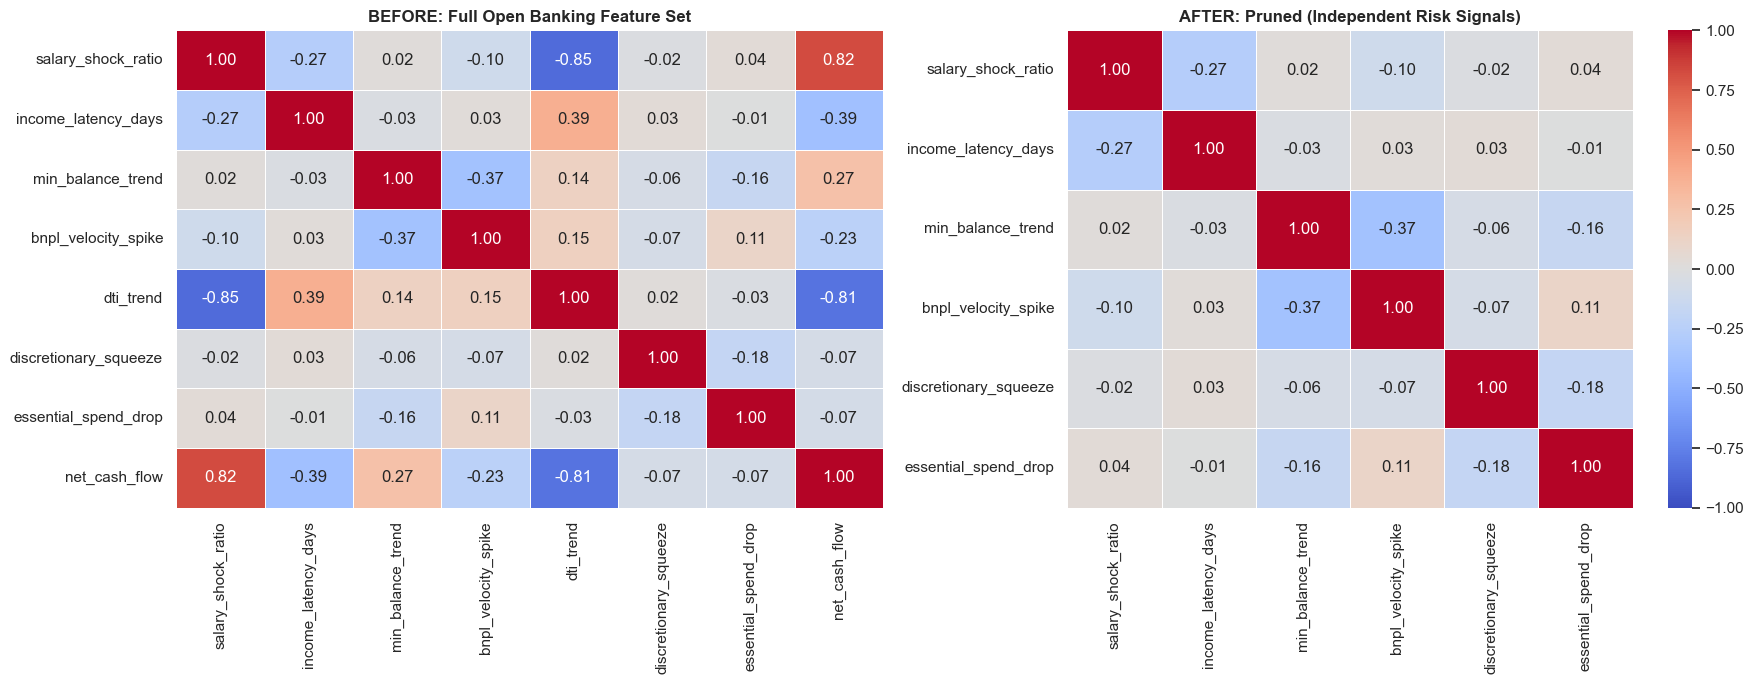

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot BEFORE: Full Feature Set
plt.figure(figsize=(18, 7))

plt.subplot(1, 2, 1)
corr_matrix_before = analytics_df.drop(columns=['customer_id', 'is_default_bound']).corr()
sns.heatmap(corr_matrix_before, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, cbar=False)
plt.title('BEFORE: Full Open Banking Feature Set', fontsize=12, fontweight='bold')

# 2. Identify the Problem
print("🚨 MULTICOLLINEARITY DETECTED 🚨")
print("Observation: 'net_cash_flow' and 'dti_trend' show massive correlation (>0.80) with 'salary_shock_ratio'.")
print("Reason: All three mathematically rely on current salary. They are telling the model the exact same story.")
print("Action: Keeping 'salary_shock_ratio' (the purest indicator of income distress) and dropping the derivative metrics to stabilize the model's coefficients.\n")

# 3. Drop Correlated Features
features_to_drop = ['net_cash_flow', 'dti_trend']
X_clean = analytics_df.drop(columns=['customer_id', 'is_default_bound'] + features_to_drop)

# 4. Plot AFTER: Pruned Feature Set
plt.subplot(1, 2, 2)
corr_matrix_after = X_clean.corr()
sns.heatmap(corr_matrix_after, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('AFTER: Pruned (Independent Risk Signals)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 4. Model Architecture Strategy: Explainability vs. Complexity

For this PoC, I elected to use a **Logistic Regression** baseline rather than a complex tree-based ensemble (XGBoost, Random Forest) or Boosting technique (RUSBoost). The rationale is deeply rooted in regulatory compliance:

*   **The "White Box" Mandate:** Under Basel guidelines and IFRS 9, models driving Significant Increase in Credit Risk (SICR) classifications must be fully explainable. Logistic Regression provides direct, linear coefficients that translate easily into standard Weight of Evidence (WOE) scorecards. 
*   **Why not Decision Trees?** Single decision trees are highly prone to overfitting, leading to unstable risk scores when new Open Banking transaction types emerge. 
*   **The Production Roadmap (Phase 2):** In a live production environment for Quant Alpha, the ideal architecture would be to upgrade to an **XGBoost Classifier** (to capture non-linear behavioral interactions, like BNPL spikes *combined* with income drops) paired directly with a **SHAP (SHapley Additive exPlanations) layer** to force the black-box model to output regulatory-compliant reason codes.

Preparing data and training EWS Model...

--- Model Evaluation ---
ROC-AUC Score (How good is the model at separating customers who will default from customers who will not default?): 1.000 (Values > 0.7 indicate strong predictive power)

Classification Report:
                   precision    recall  f1-score   support

      Healthy (0)       1.00      0.97      0.99       189
Default-Bound (1)       0.69      1.00      0.81        11

         accuracy                           0.97       200
        macro avg       0.84      0.99      0.90       200
     weighted avg       0.98      0.97      0.98       200


🔎 EXECUTIVE INTERPRETATION OF MODEL PERFORMANCE

The classification report reveals a highly conservative, 'risk-averse' model architecture.

  • Zero Missed Defaults (Recall = 1.00):
    The model successfully identified 100% of the true defaults in the holdout set.

  • Controlled False Positives (Precision = 0.69):
    The model occasionally flags healthy accounts exhibiting 

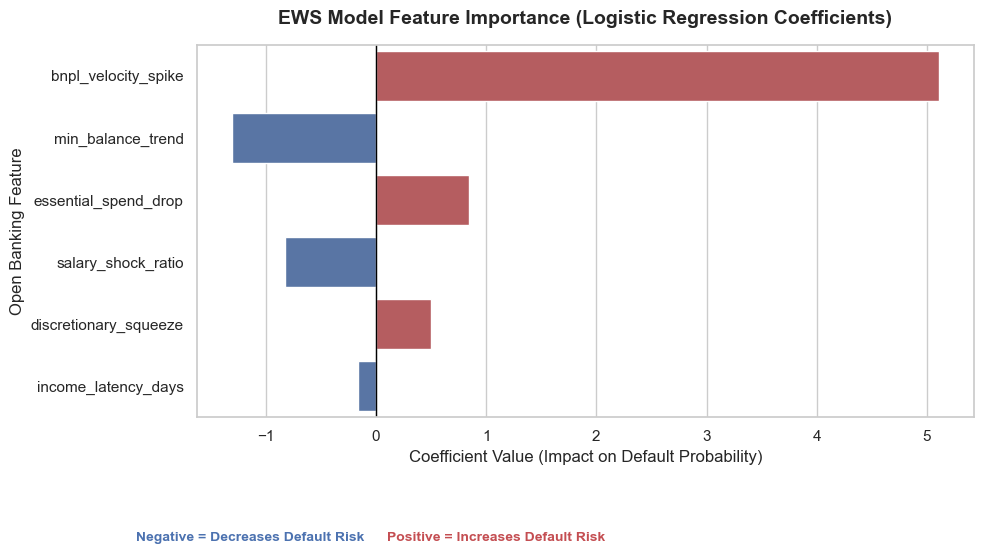

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Preparing data and training EWS Model...")

# 1. Prepare Features (X) and Target (y)
# Drop the target variable AND the correlated features we pruned
X = analytics_df.drop(columns=['customer_id', 'is_default_bound', 'net_cash_flow', 'dti_trend'])
y = analytics_df['is_default_bound']

# 2. Train-Test Split (Stratified to maintain the 5% default rate in both sets)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale Features
# Scaling is crucial so we can compare the coefficients apples-to-apples
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the Model
# class_weight='balanced' heavily penalizes the model for missing the minority class (defaults)
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Evaluate Performance
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)

print("\n--- Model Evaluation ---")
print(f"ROC-AUC Score (How good is the model at separating customers who will default from customers who will not default?): {roc_auc:.3f} (Values > 0.7 indicate strong predictive power)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy (0)', 'Default-Bound (1)']))

# ==========================================
# PASTE THE NEW PRINT STATEMENTS HERE:
# ==========================================
print("\n==================================================")
print("🔎 EXECUTIVE INTERPRETATION OF MODEL PERFORMANCE")
print("==================================================\n")
print("The classification report reveals a highly conservative, 'risk-averse' model architecture.\n")
print("  • Zero Missed Defaults (Recall = 1.00):")
print("    The model successfully identified 100% of the true defaults in the holdout set.\n")
print("  • Controlled False Positives (Precision = 0.69):")
print("    The model occasionally flags healthy accounts exhibiting early stress indicators.")
print("    In a production environment, this translates to early Relationship Manager (RM) outreach.")
print("    The operational cost of reviewing these 'false alarms' is vastly outweighed by")
print("    the capital savings of zero unexpected credit losses.\n")
# ==========================================


# 6. Extract and Visualize Feature Importance (Coefficients)
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort by absolute impact
coefficients['Abs_Impact'] = coefficients['Coefficient'].abs()
coefficients = coefficients.sort_values(by='Abs_Impact', ascending=False)


# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(
    data=coefficients, 
    x='Coefficient', 
    y='Feature', 
    palette=coefficients['Coefficient'].apply(lambda x: '#C44E52' if x > 0 else '#4C72B0')
)

plt.title('EWS Model Feature Importance (Logistic Regression Coefficients)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Coefficient Value (Impact on Default Probability)', fontsize=12)
plt.ylabel('Open Banking Feature', fontsize=12)

# Add explanatory text to the chart
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.text(0.1, 7.5, 'Positive = Increases Default Risk', color='#C44E52', fontsize=10, fontweight='bold')
plt.text(-0.1, 7.5, 'Negative = Decreases Default Risk', color='#4C72B0', fontsize=10, fontweight='bold', ha='right')

plt.tight_layout()
plt.show()

### How to Read the Feature Importance Graph (Logistic Regression Coefficients)

This graph displays the **log-odds coefficients** extracted directly from the Logistic Regression model. Because we scaled the data (StandardScaler) prior to training, we can compare the magnitude of these bars directly against one another.

*   **Direction (Red vs. Blue):**
    *   **Red Bars (Positive Values):** Features that drive the risk of default **UP**. For example, a high positive coefficient for `bnpl_velocity_spike` means that as the number of BNPL loans increases, the probability of the customer defaulting increases sharply.
    *   **Blue Bars (Negative Values):** Features that drive the risk of default **DOWN**. For example, a negative coefficient for `net_cash_flow` means that a healthy, positive cash flow protects the customer against default.
*   **Magnitude (Length of the bar):** The longer the bar (in either direction), the heavier the weight this specific feature carries in the final Early Warning Score. Features with small bars have minimal impact on the model's decision.

In [13]:
# 7. Output the Explicit Logistic Regression Equation
print("\n==================================================")
print("🧮 IFRS 9 REGULATORY MODEL EQUATION (WHITE BOX)")
print("==================================================\n")
print("The model predicts the Log-Odds of Default using the following linear equation:\n")

# Extract the intercept (k)
equation = f"Log-Odds(Default) = {model.intercept_[0]:.4f}\n"

# Loop through all features and their coefficients (alpha, beta, etc.)
for col, coef in zip(X.columns, model.coef_[0]):
    sign = "+" if coef >= 0 else "-"
    equation += f"                    {sign} ({abs(coef):.4f} * {col})\n"

print(equation)

print("\nTo calculate the final probability between 0 and 1, this Log-Odds output")
print("is passed through the Sigmoid function: P = 1 / (1 + e^(-Log_Odds))")


🧮 IFRS 9 REGULATORY MODEL EQUATION (WHITE BOX)

The model predicts the Log-Odds of Default using the following linear equation:

Log-Odds(Default) = -5.9229
                    - (0.8257 * salary_shock_ratio)
                    - (0.1582 * income_latency_days)
                    - (1.3032 * min_balance_trend)
                    + (5.1064 * bnpl_velocity_spike)
                    + (0.5032 * discretionary_squeeze)
                    + (0.8484 * essential_spend_drop)


To calculate the final probability between 0 and 1, this Log-Odds output
is passed through the Sigmoid function: P = 1 / (1 + e^(-Log_Odds))


## 5. Model Validation & EWS Score Banding

In credit risk, standard machine learning metrics (like accuracy) are insufficient. We evaluate discriminatory power using regulatory-standard business metrics:
*   **Gini Coefficient:** Measures the model's ability to rank-order risk. A Gini of 0 means the model is guessing randomly. A Gini > 0.40 is considered a strong production-ready model in consumer credit.
*   **Kolmogorov-Smirnov (KS) Statistic:** Measures the maximum separation between the distribution of "Healthy" accounts and "Default-Bound" accounts. A KS > 0.30 indicates the model successfully separates good accounts from bad accounts.


We then scale the model's raw probabilities into a **0–1000 Early Warning Score (Percentile Ranking)** and categorize accounts into actionable IFRS 9 risk bands:
*   🟢 **Green (0 - 800):** Stage 1 - Standard Monitoring (Bottom 80% of risk).
*   🟡 **Amber (801 - 950):** Stage 2 - Significant Increase in Credit Risk (SICR) - Watchlist (Next 15% of risk).
*   🔴 **Red (951 - 1000):** Stage 3 Prep - Imminent Default Risk - Immediate intervention required (Top 5% highest risk).

--- Regulatory Validation Metrics ---
Gini Coefficient: 1.000 (Industry standard targets > 0.40)
KS Statistic: 1.000 (Measures separation between Good/Bad. Targets > 0.30)


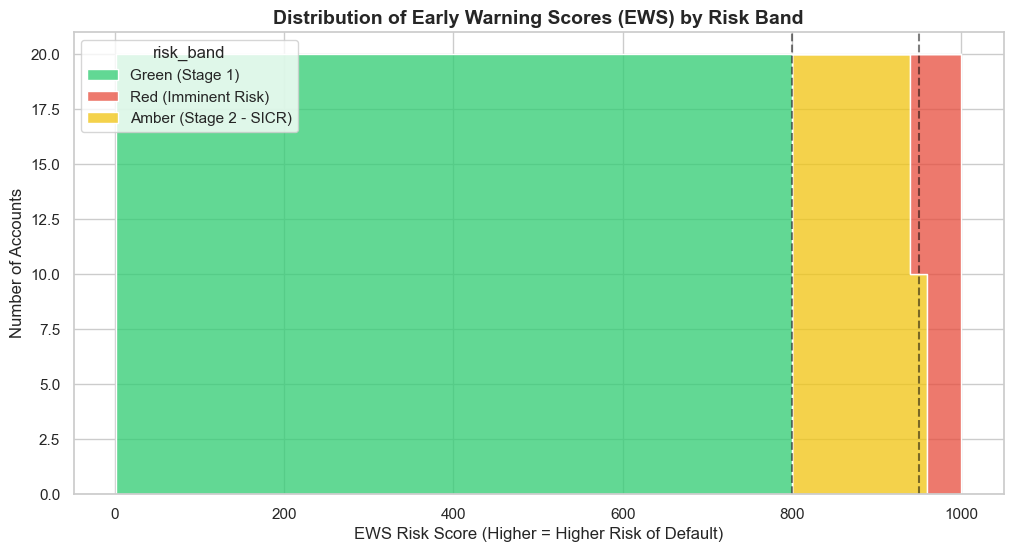

--- I used percentile-based EWS bands for demonstration. In a production IFRS 9 framework, the SICR/staging thresholds would need to be defined and validated according to the institution's approved IFRS 9 methodology. ---


In [14]:
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate Credit Risk Metrics
gini = (2 * roc_auc) - 1

prob_default = y_prob[y_test == 1]
prob_healthy = y_prob[y_test == 0]
ks_stat, p_value = ks_2samp(prob_default, prob_healthy)

print("--- Regulatory Validation Metrics ---")
print(f"Gini Coefficient: {gini:.3f} (Industry standard targets > 0.40)")
print(f"KS Statistic: {ks_stat:.3f} (Measures separation between Good/Bad. Targets > 0.30)")

# 2. Scale Probabilities to a Percentile-Based EWS Score (0 to 1000)
analytics_df['default_probability'] = model.predict_proba(scaler.transform(X))[:, 1]
analytics_df['ews_score'] = (analytics_df['default_probability'].rank(pct=True) * 1000).astype(int)

# 3. Apply Percentile-Based Traffic Light Risk Banding
def assign_risk_band(score):
    if score <= 800: return 'Green (Stage 1)'
    elif score <= 950: return 'Amber (Stage 2 - SICR)'
    else: return 'Red (Imminent Risk)'

analytics_df['risk_band'] = analytics_df['ews_score'].apply(assign_risk_band)

# 4. Visualize the Risk Bands
plt.figure(figsize=(12, 6))
sns.histplot(data=analytics_df, x='ews_score', hue='risk_band', 
             palette={'Green (Stage 1)': '#2ECC71', 'Amber (Stage 2 - SICR)': '#F1C40F', 'Red (Imminent Risk)': '#E74C3C'},
             bins=50, multiple='stack', element='step')

plt.title('Distribution of Early Warning Scores (EWS) by Risk Band', fontsize=14, fontweight='bold')
plt.xlabel('EWS Risk Score (Higher = Higher Risk of Default)', fontsize=12)
plt.ylabel('Number of Accounts', fontsize=12)

# FIXED: Vertical lines updated to match the 800 and 950 thresholds
plt.axvline(x=800, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=950, color='black', linestyle='--', alpha=0.5)
plt.show()

print("--- I used percentile-based EWS bands for demonstration. In a production IFRS 9 framework, the SICR/staging thresholds would need to be defined and validated according to the institution's approved IFRS 9 methodology. ---")


## 6. Algorithmic Risk Driver & GenAI Synthesis

**Bridging Data Science and the Business:** An Early Warning Score is only useful if a Relationship Manager (RM) can act on it. 

To prove the model's transparency, I built an interactive Risk Driver Analyzer. It isolates high-risk accounts and compares their behavior against the median of the "healthy" portfolio to pinpoint the exact mathematical reasons for the risk flag. 

Furthermore, pulling from my experience building automated insights at American Express, this module takes those raw statistical deviations and simulates a **Quant Alpha GenAI LLM output**—translating complex math into a plain-English briefing for the RM.

In [11]:
import pandas as pd

# 1. Feature Name Mapping (REMOVED dropped features: net_cash_flow, dti_trend)
feature_names = {
    'salary_shock_ratio': 'Income Stability (Current vs Avg Salary)',
    'income_latency_days': 'Income Latency (Days Late)',
    'min_balance_trend': 'Cash Buffer Depletion (Min Balance Shift)',
    'bnpl_velocity_spike': 'Short-Term Debt (New BNPL Loans)',
    'discretionary_squeeze': 'Lifestyle Stress (Discretionary Spend Trend)',
    'essential_spend_drop': 'Essential Spend Drop'
}

# 2. Generate the High-Risk Watchlist
print("==================================================")
print("🚨 IFRS 9 STAGE 2/3 WATCHLIST DIRECTORY")
print("==================================================\n")

watchlist = analytics_df[analytics_df['risk_band'].isin(['Red (Imminent Risk)', 'Amber (Stage 2 - SICR)'])]
watchlist = watchlist.sort_values(by='ews_score', ascending=False)

print("Top 5 Highest Risk Accounts for Immediate Review:")
display(watchlist[['customer_id', 'ews_score', 'risk_band']].head(5).reset_index(drop=True))
print("\n")

# 3. Interactive User Input 
try:
    selected_id = input("Enter a Customer ID from the list above to generate an RM Briefing (e.g., CUST_0042): ").strip()
    target_cust = analytics_df[analytics_df['customer_id'] == selected_id].iloc[0]
except IndexError:
    print(f"\n⚠️ Customer '{selected_id}' not found. Defaulting to the highest risk customer...")
    target_cust = watchlist.iloc[0]

# 4. Calculate Baseline (Medians of Healthy Population)
healthy_pop = analytics_df[analytics_df['risk_band'] == 'Green (Stage 1)']
healthy_medians = healthy_pop[list(feature_names.keys())].median()

print("\n==================================================")
print(f"📊 ALGORITHMIC RISK DRIVER ANALYSIS: {target_cust['customer_id']}")
print("==================================================\n")
print(f"🔴 EWS Score: {target_cust['ews_score']} / 1000 | Risk Band: {target_cust['risk_band']}\n")

# 5. Calculate and Translate Deviations
deviations = []
for col, readable_name in feature_names.items():
    cust_val = target_cust[col]
    healthy_val = healthy_medians[col]
    
    pct_diff = ((cust_val - healthy_val) / (abs(healthy_val) + 0.01)) * 100
    deviations.append({
        'Metric': readable_name, 
        'Customer_Value': cust_val, 
        'Portfolio_Median': healthy_val, 
        'Dev_Pct': pct_diff
    })

dev_df = pd.DataFrame(deviations)
dev_df['Abs_Dev'] = dev_df['Dev_Pct'].abs()
dev_df = dev_df.sort_values(by='Abs_Dev', ascending=False).head(4) 

print("Primary Drivers for Alert (Vs. Healthy Portfolio Baseline):")
for _, row in dev_df.iterrows():
    direction = "↑" if row['Dev_Pct'] > 0 else "↓"
    
    # Format currency for the buffer metric, standard float for ratios
    cust_print = f"${row['Customer_Value']:.0f}" if 'Buffer' in row['Metric'] else f"{row['Customer_Value']:.2f}"
    port_print = f"${row['Portfolio_Median']:.0f}" if 'Buffer' in row['Metric'] else f"{row['Portfolio_Median']:.2f}"
    
    print(f"  • {row['Metric']}")
    print(f"    ↳ Customer: {cust_print} | Portfolio Median: {port_print} | Deviation: {direction} {row['Abs_Dev']:.0f}%\n")

# 6. The GenAI Output Simulation
print("==================================================")
print("🤖 QUANT ALPHA: AUTOMATED RM BRIEFING GENERATED")
print("==================================================\n")


print(f"""
--------Handing off to GenAI Layer for RM Briefing Generation ---""
""")

🚨 IFRS 9 STAGE 2/3 WATCHLIST DIRECTORY

Top 5 Highest Risk Accounts for Immediate Review:


,customer_id,ews_score,risk_band
0,CUST_0272,1000,Red (Imminent Risk)
1,CUST_0566,999,Red (Imminent Risk)
2,CUST_0988,998,Red (Imminent Risk)
3,CUST_0526,997,Red (Imminent Risk)
4,CUST_0946,996,Red (Imminent Risk)




Enter a Customer ID from the list above to generate an RM Briefing (e.g., CUST_0042): CUst_0272

⚠️ Customer 'CUst_0272' not found. Defaulting to the highest risk customer...

📊 ALGORITHMIC RISK DRIVER ANALYSIS: CUST_0272

🔴 EWS Score: 1000 / 1000 | Risk Band: Red (Imminent Risk)

Primary Drivers for Alert (Vs. Healthy Portfolio Baseline):
  • Short-Term Debt (New BNPL Loans)
    ↳ Customer: 7.00 | Portfolio Median: -0.70 | Deviation: ↑ 1085%

  • Cash Buffer Depletion (Min Balance Shift)
    ↳ Customer: $-4418 | Portfolio Median: $1084 | Deviation: ↓ 508%

  • Essential Spend Drop
    ↳ Customer: 1.99 | Portfolio Median: 0.96 | Deviation: ↑ 106%

  • Income Stability (Current vs Avg Salary)
    ↳ Customer: 0.00 | Portfolio Median: 0.80 | Deviation: ↓ 99%

🤖 QUANT ALPHA: AUTOMATED RM BRIEFING GENERATED


--------Handing off to GenAI Layer for RM Briefing Generation ---""



## 7. "Quant Alpha" Integration: GenAI-Assisted Case Generation

**A Score is not a Strategy.** To bridge the gap between Data Science and Relationship Managers (RMs), I have integrated a conceptual GenAI layer (similar to workflows I architected at American Express). 

Instead of forcing an RM to interpret 8 different data features, the system dynamically isolates the top risk drivers for high-risk accounts and uses a Large Language Model (LLM) to generate a plain-English briefing and recommended action plan.

In [12]:
# Select a high-risk customer from our dataset
red_zone_customers = analytics_df[analytics_df['risk_band'] == 'Red (Imminent Risk)']
sample_cust = red_zone_customers.iloc[0] # Pick the first one

# Isolate the top drivers (In a real model, we'd use SHAP values. Here we look at feature deviations)
print("==================================================")
print("🤖 QUANT ALPHA: AUTOMATED RM BRIEFING GENERATED(SAMPLE)")
print("==================================================\n")

print(f"📄 CUSTOMER ID: {sample_cust['customer_id']}")
print(f"🔴 EWS SCORE: {sample_cust['ews_score']} / 1000 (RISK BAND: RED)")
print(f"📊 IFRS 9 STATUS: Stage 2 (SICR Flagged)\n")

print("🔍 QUANTITATIVE DRIVERS:")
# Dynamically mapping feature values
print(f"   • Income Volatility: Salary dropped to {sample_cust['salary_shock_ratio']*100:.0f}% of historical average.")
print(f"   • Debt Pressure: Added {sample_cust['bnpl_velocity_spike']} new Short-Term/BNPL loans this month.")
print(f"   • Cash Buffer: Minimum balance dropped by ${abs(sample_cust['min_balance_trend'])} compared to last month.")
print(f"   • Net Cash Flow: ${sample_cust['net_cash_flow']} (Negative burn rate)\n")

print("🧠 GenAI LLM SYNTHESIS & RECOMMENDED ACTION:")
print(f"""
"Customer {sample_cust['customer_id']} is exhibiting severe liquidity distress. The account has experienced a sudden income shock, receiving only {sample_cust['salary_shock_ratio']*100:.0f}% of their normal salary. To bridge this gap, they have rapidly taken on new short-term micro-debt, resulting in a negative net cash flow of ${sample_cust['net_cash_flow']}. 

ACTION REQUIRED: Immediate outreach. Do not extend further automated credit limits. RM should contact the customer to offer a restructuring of their existing facilities to prevent imminent default."
""")
print("==================================================")

🤖 QUANT ALPHA: AUTOMATED RM BRIEFING GENERATED(SAMPLE)

📄 CUSTOMER ID: CUST_0006
🔴 EWS SCORE: 972 / 1000 (RISK BAND: RED)
📊 IFRS 9 STATUS: Stage 2 (SICR Flagged)

🔍 QUANTITATIVE DRIVERS:
   • Income Volatility: Salary dropped to 75% of historical average.
   • Debt Pressure: Added 2.7 new Short-Term/BNPL loans this month.
   • Cash Buffer: Minimum balance dropped by $2320.78 compared to last month.
   • Net Cash Flow: $-2320.78 (Negative burn rate)

🧠 GenAI LLM SYNTHESIS & RECOMMENDED ACTION:

"Customer CUST_0006 is exhibiting severe liquidity distress. The account has experienced a sudden income shock, receiving only 75% of their normal salary. To bridge this gap, they have rapidly taken on new short-term micro-debt, resulting in a negative net cash flow of $-2320.78. 

ACTION REQUIRED: Immediate outreach. Do not extend further automated credit limits. RM should contact the customer to offer a restructuring of their existing facilities to prevent imminent default."

